In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
import string
import json
import os
from datetime import datetime

In [2]:
# News sources dictionary
RSS_SOURCES = {
    "BBC News": "https://feeds.bbci.co.uk/news/rss.xml",
    "CNBC": "https://www.cnbc.com/id/100003114/device/rss/rss.html",
    "Al Jazeera": "https://www.aljazeera.com/xml/rss/all.xml",
}

# Hacker News endpoints
HACKERNEWS_URL = "https://hacker-news.firebaseio.com/v0/topstories.json"

# Header configuration
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; NewsAnalyzer/1.0)"}

In [3]:
def fetch_rss_headlines(sources):
    # Store all headlines
    all_headlines = []

    for source_name, url in sources.items():
        try:
            # Request website data
            response = requests.get(url, headers=HEADERS, timeout=10)
            soup = BeautifulSoup(response.content, "xml")

            # Find item tags
            items = soup.find_all("item")

            for item in items:
                title = item.find("title").text.strip()
                all_headlines.append({
                    "headline": title,
                    "source": source_name,
                    "fetched_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                })
        except Exception as e:
            # Print error message
            print(f"Error fetching {source_name}: {e}")

    return all_headlines


def fetch_hackernews_headlines(url, limit=25):
    # Store hackernews headlines
    hn_headlines = []

    try:
        # Get top stories
        response = requests.get(url, headers=HEADERS, timeout=10)
        story_ids = response.json()[:limit]

        for story_id in story_ids:
            try:
                # Get item details
                item_url = f"https://hacker-news.firebaseio.com/v0/item/{story_id}.json"
                item_response = requests.get(item_url, headers=HEADERS, timeout=5)
                item_data = item_response.json()

                if item_data and "title" in item_data:
                    hn_headlines.append({
                        "headline": item_data["title"],
                        "source": "Hacker News",
                        "fetched_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                    })
            except Exception:
                # Skip broken items
                continue
    except Exception as e:
        # Print error message
        print(f"Error fetching Hacker News: {e}")

    return hn_headlines

In [4]:
# Fetch from RSS
rss_data = fetch_rss_headlines(RSS_SOURCES)

# Fetch from HN
hn_data = fetch_hackernews_headlines(HACKERNEWS_URL, limit=25)

# Combine all data
combined_data = rss_data + hn_data

# Create initial dataframe
df = pd.DataFrame(combined_data)

# Show dataframe info
print(f"Total headlines collected: {len(df)}")
df.head()

Total headlines collected: 113


,headline,source,fetched_at
0,Lammy says he told JD Vance his Nowak comments...,BBC News,2026-06-07 19:29:35
1,Zelensky arrives in UK for Downing Street talk...,BBC News,2026-06-07 19:29:35
2,"M&S launches new traineeship for 1,000 young p...",BBC News,2026-06-07 19:29:35
3,Steve Rosenberg: Russia's economic forum overs...,BBC News,2026-06-07 19:29:35
4,Son calls for Iran prisoner exchange for Briti...,BBC News,2026-06-07 19:29:35


In [5]:
# Stopwords set declaration
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "as", "is", "it", "its", "be", "by", "from", "that",
    "this", "was", "are", "were", "has", "have", "had", "not", "he", "she",
    "they", "we", "you", "i", "his", "her", "their", "our", "your", "my",
    "will", "can", "could", "would", "should", "may", "might", "do", "did",
    "does", "after", "before", "about", "over", "into", "up", "out", "than",
    "more", "also", "been", "new", "says", "say", "said", "one", "two",
    "three", "four", "five", "us", "uk", "s", "amid", "how", "who", "what",
    "when", "where", "why", "all", "just", "get"
}


def clean_headline(text):
    # Convert to lowercase
    text = text.lower()

    # Remove web urls
    text = re.sub(r"https?://\s+|www\.\s+", "", text)

    # Remove punctuation tokens
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numeric digits
    text = re.sub(r"\d+", "", text)

    # Split into words
    words = text.split()

    # Filter out stopwords
    filtered_words = [w for w in words if w not in STOPWORDS]

    # Rejoin cleaned words
    return " ".join(filtered_words)

In [6]:
# Drop empty rows
df = df.dropna(subset=["headline"])

# Apply text cleaning
df["cleaned_headline"] = df["headline"].apply(clean_headline)

# Show cleaning results
df[["headline", "cleaned_headline"]].head()

,headline,cleaned_headline
0,Lammy says he told JD Vance his Nowak comments...,lammy told jd vance nowak comments wrong
1,Zelensky arrives in UK for Downing Street talk...,zelensky arrives downing street talks european...
2,"M&S launches new traineeship for 1,000 young p...",ms launches traineeship young people
3,Steve Rosenberg: Russia's economic forum overs...,steve rosenberg russias economic forum oversha...
4,Son calls for Iran prisoner exchange for Briti...,son calls iran prisoner exchange british pair


In [7]:
def get_word_frequencies(dataframe, source_filter=None):
    # Filter by source
    if source_filter:
        target_df = dataframe[dataframe["source"] == source_filter]
    else:
        target_df = dataframe

    # Combine all headlines
    all_text = " ".join(target_df["cleaned_headline"].tolist())

    # Split into single tokens
    tokens = all_text.split()

    # Count token frequencies
    return Counter(tokens)


def create_frequency_dataframe(counter_object, limit=10):
    # Get most common
    most_common = counter_object.most_common(limit)

    # Convert to dataframe
    freq_df = pd.DataFrame(most_common, columns=["word", "frequency"])
    return freq_df

In [8]:
# Extract overall frequencies
overall_counts = get_word_frequencies(df)
df_overall_freq = create_frequency_dataframe(overall_counts, limit=10)

# Extract source specific frequencies
sources = df["source"].unique()
source_dfs = {}

for src in sources:
    src_counts = get_word_frequencies(df, source_filter=src)
    source_dfs[src] = create_frequency_dataframe(src_counts, limit=10)

# Print overall top words
print("Overall top 5 words:")
print(df_overall_freq.head(5))


Overall top 5 words:
     word  frequency
0  israel          6
1      ai          6
2   world          5
3     cup          5
4       –          5


In [18]:
def plot_news_trends(overall_df, source_dict):
    # Determine source count
    num_sources = len(source_dict)

    # Initialize figure size
    fig = plt.figure(figsize=(16, 12),constrained_layout=True)

    # Create grid layout
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    # Plot overall frequencies
    ax_main = fig.add_subplot(gs[0, :])
    sns.barplot(x="frequency", y="word", hue="word", data=overall_df, ax=ax_main, palette="Blues_r", legend=False)
    ax_main.set_title("Top 10 Most Frequent Words Across All Sources", fontsize=14)
    ax_main.set_xlabel("Frequency Count")
    ax_main.set_ylabel("Words")

    # Plot source specific
    source_index = 0
    for source_name, src_df in source_dict.items():
        if src_df is None or src_df.empty:
            continue

        row = 1 + (source_index // 2)
        col = source_index % 2

        ax_sub = fig.add_subplot(gs[row, col])
        sns.barplot(x="frequency", y="word", hue="word", data=src_df, ax=ax_sub, palette="viridis", legend=False)
        ax_sub.set_title(f"Top Words in {source_name}", fontsize=12)
        ax_sub.set_xlabel("Frequency Count")
        ax_sub.set_ylabel("Words")

        source_index += 1
    plt.show()

{'BBC News':         word  frequency
0      lammy          2
1         jd          2
2      vance          2
3      nowak          2
4   comments          2
5      wrong          2
6      royal          2
7      years          2
8  antonelli          2
9       wins          2, 'Hacker News':           word  frequency
0            –          5
1     software          3
2         llms          2
3  engineering          2
4         show          2
5           hn          2
6       domain          2
7      machine          2
8           kv          2
9      vitamin          1}


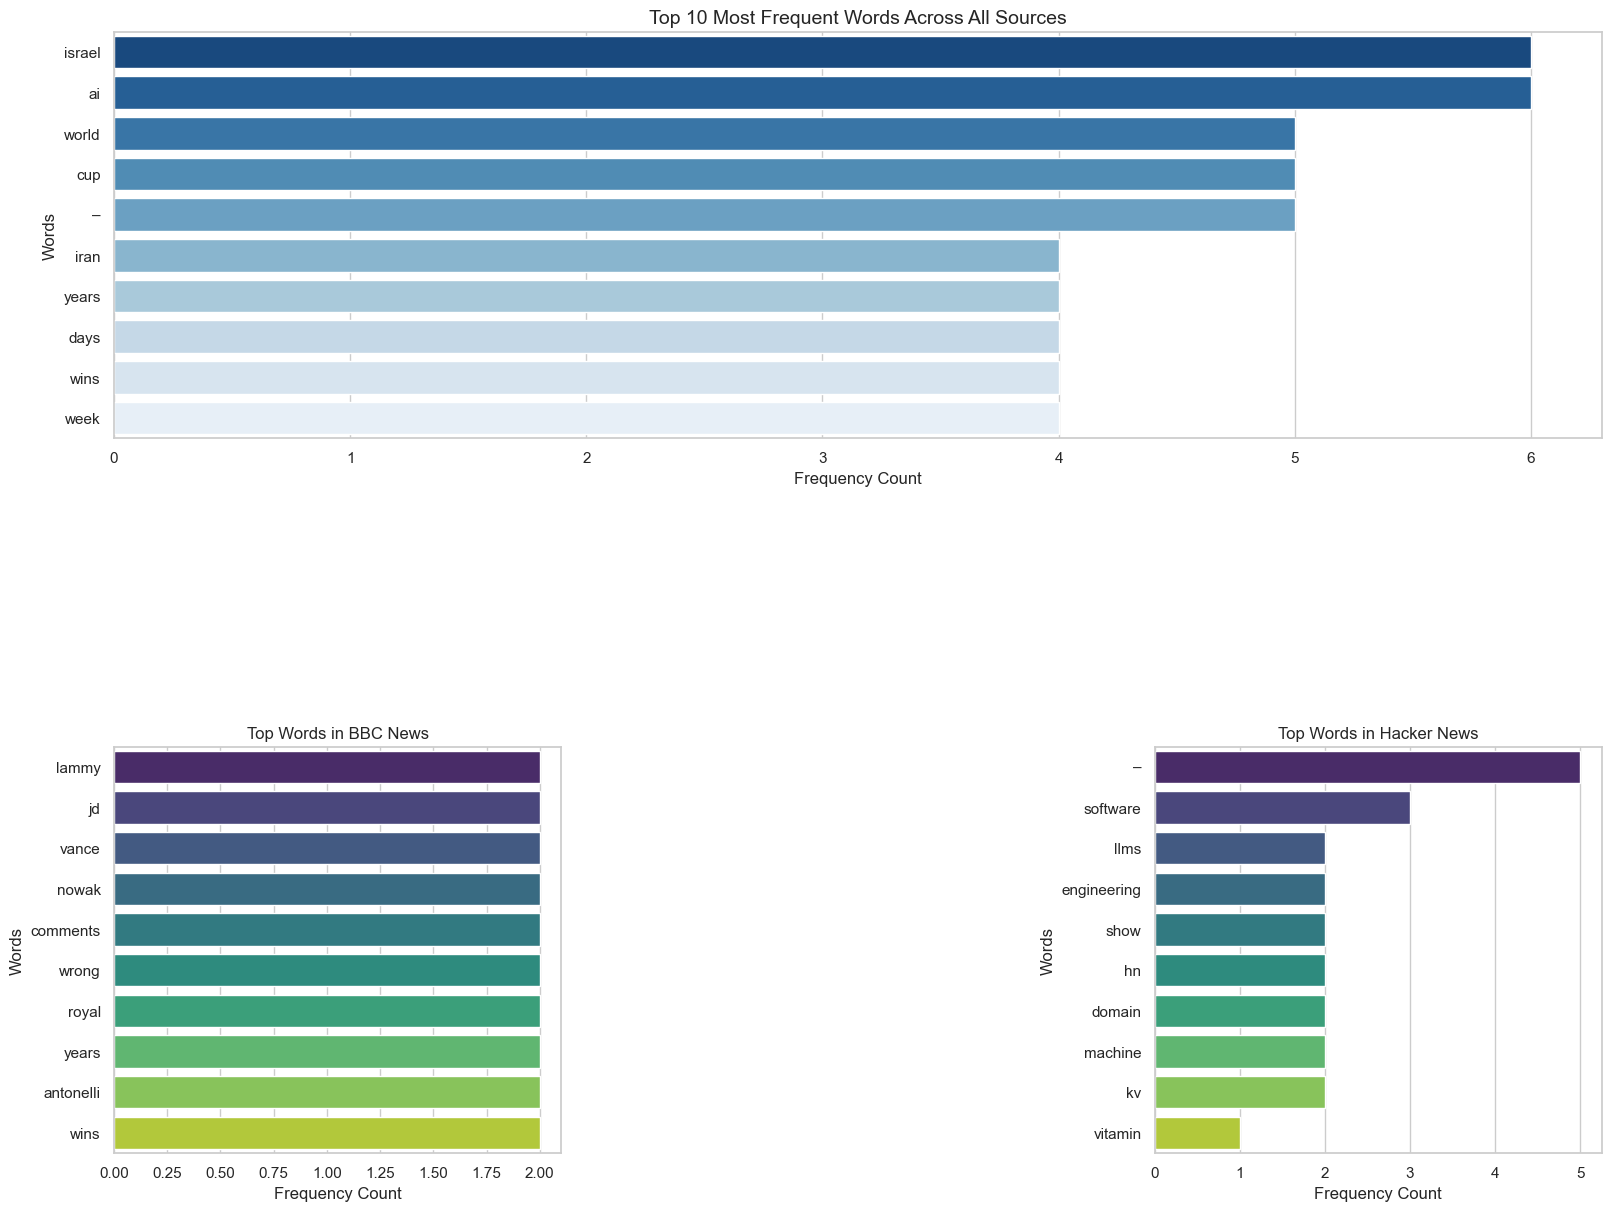

In [19]:
# Set plot style
sns.set_theme(style="whitegrid")

# Create visualization dictionary
target_sources = {
    "BBC News": source_dfs.get("BBC News"),
    "Hacker News": source_dfs.get("Hacker News")
}

# Generate trend plots
print(target_sources)
plot_news_trends(df_overall_freq, target_sources)

In [20]:
def export_pipeline_outputs(overall_freq_df, clean_df):
    # Define output names
    freq_file = "top_word_news_frequencies.csv"
    archive_file = "cleaned_news_headlines_archive.csv"

    # Save frequency data
    overall_freq_df.to_csv(freq_file, index=False)

    # Save archived headlines
    clean_df.to_csv(archive_file, index=False)

    # Print status message
    print("Pipeline outputs saved successfully")

# Execute storage export
export_pipeline_outputs(df_overall_freq, df)

Pipeline outputs saved successfully
